# CMR Boundary-Signal Simulation — Targeted Comparison

This notebook runs three conditions through an 18-item list with boundaries at positions 7 and 13 (three 6-item segments). Each condition specifies a (non-boundary, boundary) drift pair:

| Condition | Non-boundary drift | Boundary drift | Interpretation |
|---|---|---|---|
| **Baseline** | 0.6 | 0.8 | Healthy encoding with intact boundary boost |
| **H1 — Boundary impairment** | 0.6 | 0.6 | Boundary boost abolished; tonic drift intact |
| **H2 — Global reduction** | 0.4 | 0.6 | All drifts lowered; boundary still above baseline |

All conditions force the first item (position 1) to drift = 1.0.

H1 and H2 share the same boundary drift (0.6) but differ in their non-boundary drift. The question is whether these two routes to impaired recall leave distinguishable signatures in boundary-local transitions, SPC, lag-CRP, and overall accuracy.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings, importlib
warnings.filterwarnings("ignore")

import src.config as cfg
import src.simulation as sim
import src.metrics as met

importlib.reload(cfg)
importlib.reload(sim)
importlib.reload(met)


N    = cfg.N
bps  = cfg.BOUNDARY_POSITIONS
N_SIMS = cfg.N_SIMS
SEED   = cfg.SEED

positions = np.arange(1, N + 1)

print(f"N = {N}, boundaries at {bps}, {N_SIMS} sims per condition")

N = 18, boundaries at [7, 13], 1000 sims per condition


## Define conditions and drift schedules

Each condition is a `(non-boundary, boundary)` drift pair. The schedules are built with `build_global_schedule`, which assigns one drift to non-boundary positions and another to boundary positions. Position 1 is always forced to drift = 1.0.

In [2]:
CONDITIONS = {
    "Baseline (0.6 / 0.8)": (0.6, 0.8),
    "H1: boundary impaired (0.6 / 0.6)": (0.6, 0.6),
    "H2: global reduction (0.4 / 0.6)": (0.4, 0.6),
}

schedules = {}
for label, (b_non, b_bdy) in CONDITIONS.items():
    schedules[label] = sim.build_global_schedule(b_non, b_bdy)
    print(sim.describe_schedule(schedules[label]))
    print()

N = 18, boundaries at [7, 13]
non-boundary drift: mean 0.625 (range 0.600–1.000)
  (position 1 forced to 1.0)
boundary drift:     0.800 (range 0.800–0.800)

N = 18, boundaries at [7, 13]
non-boundary drift: mean 0.625 (range 0.600–1.000)
  (position 1 forced to 1.0)
boundary drift:     0.600 (range 0.600–0.600)

N = 18, boundaries at [7, 13]
non-boundary drift: mean 0.438 (range 0.400–1.000)
  (position 1 forced to 1.0)
boundary drift:     0.600 (range 0.600–0.600)



### Visualize drift schedules

The step-function plots below show the per-position encoding drift for each condition. Vertical dashed lines mark boundary positions. Small vertical offsets are for visual separation only; true values are unchanged. Position 1 is always at 1.0.

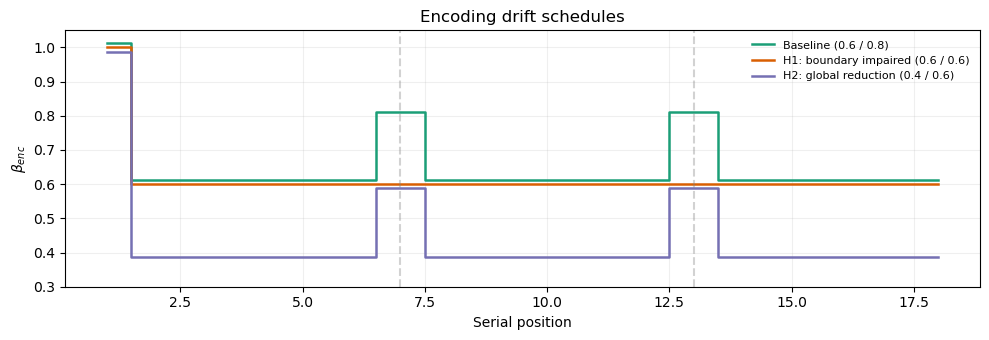

In [3]:
COLORS = {
    "Baseline (0.6 / 0.8)": "#1b9e77",
    "H1: boundary impaired (0.6 / 0.6)": "#d95f02",
    "H2: global reduction (0.4 / 0.6)": "#7570b3",
}

OFFSETS = {
    "Baseline (0.6 / 0.8)":  0.012,
    "H1: boundary impaired (0.6 / 0.6)": 0.0,
    "H2: global reduction (0.4 / 0.6)": -0.012,
}

fig, ax = plt.subplots(figsize=(10, 3.5))

for label, B in schedules.items():
    B_plot = np.asarray(B) + OFFSETS[label]
    ax.step(
        positions, B_plot, where='mid',
        lw=1.8, label=label, color=COLORS[label]
    )

for j in bps:
    ax.axvline(j, color='grey', ls='--', alpha=0.35)

ax.set(
    xlabel='Serial position',
    ylabel=r'$\beta_{enc}$',
    title='Encoding drift schedules',
    ylim=(0.3, 1.05)
)
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Run simulations

In [4]:
results = {}
for label, B in schedules.items():
    print(f"  {label} ...", end=" ")
    results[label] = sim.run_batch(B, n_sims=N_SIMS, seed=SEED, label=label)
    acc = met.recall_accuracy(results[label]['recall_sims'], N)
    print(f"done  (accuracy = {acc:.3f})")

  Baseline (0.6 / 0.8) ... done  (accuracy = 0.314)
  H1: boundary impaired (0.6 / 0.6) ... done  (accuracy = 0.335)
  H2: global reduction (0.4 / 0.6) ... done  (accuracy = 0.537)


## Whole-list metrics

For each condition: compute whole-list metrics (SPC, PFR, lag-CRP, recall accuracy), boundary-local metrics (three lag-1 transitions around each boundary, boundary-local SPC), and proportion recalled (recalled from each context segment).

In [5]:
summaries = {}
for label, res in results.items():
    summaries[label] = met.summarize_condition_metrics(res['recall_sims'], N)

# Boundary transitions + segment recall table
print(f"{'Condition':<40s}  {'(j-1)→j':>8s}  {'j→(j-1)':>8s}  {'j→(j+1)':>8s}  {'Accuracy':>8s}  {'TrainMean':>9s}")
print('-' * 95)
for label, s in summaries.items():
    print(f"{label:<40s}  "
          f"{s['pre_to_boundary']:8.4f}  "
          f"{s['boundary_backward']:8.4f}  "
          f"{s['boundary_forward']:8.4f}  "
          f"{s['recall_accuracy']:8.4f}  "
          f"{s['mean_train_recall']:9.4f}")

# Per-segment breakdown
train_ids, mean_tr_base, se_tr_base = list(summaries.values())[0]['train_recall']
bounds = list(summaries.values())[0]['train_bounds']
header = f"{'Condition':<40s}" + "".join(f"  {'T'+str(t)+' ('+str(b[0])+'-'+str(b[1])+')':>15s}" for t, b in zip(train_ids, bounds))
print("\n" + header)
print('-' * (40 + 17 * len(train_ids)))
for label, s in summaries.items():
    _, mean_tr, se_tr = s['train_recall']
    row = f"{label:<40s}"
    for m, se in zip(mean_tr, se_tr):
        row += f"  {m:7.3f} ±{se:.3f}"
    print(row)

Condition                                  (j-1)→j   j→(j-1)   j→(j+1)  Accuracy  TrainMean
-----------------------------------------------------------------------------------------------
Baseline (0.6 / 0.8)                        0.2817    0.1016    0.3905    0.3144     0.3144
H1: boundary impaired (0.6 / 0.6)           0.2830    0.2201    0.3982    0.3350     0.3350
H2: global reduction (0.4 / 0.6)            0.2639    0.0956    0.2155    0.5368     0.5368

Condition                                        T1 (1-6)        T2 (7-12)       T3 (13-18)
-------------------------------------------------------------------------------------------
Baseline (0.6 / 0.8)                        0.010 ±0.002    0.069 ±0.004    0.864 ±0.005
H1: boundary impaired (0.6 / 0.6)           0.015 ±0.002    0.148 ±0.006    0.842 ±0.005
H2: global reduction (0.4 / 0.6)            0.148 ±0.007    0.536 ±0.010    0.927 ±0.004


### Serial position curve

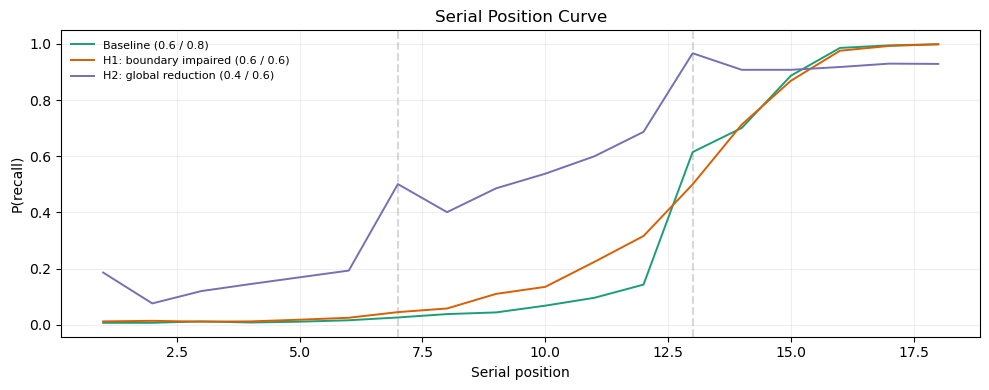

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, s in summaries.items():
    ax.plot(positions, s['whole_spc'], lw=1.4, label=label, color=COLORS[label])
for j in bps:
    ax.axvline(j, color='grey', ls='--', alpha=0.3)
ax.set(xlabel='Serial position', ylabel='P(recall)',
       title='Serial Position Curve')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Probability of first recall

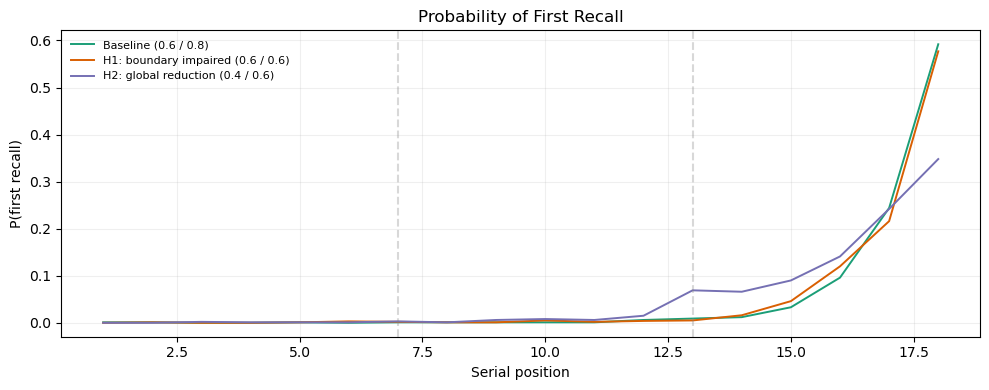

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, s in summaries.items():
    ax.plot(positions, s['whole_pfr'], lw=1.4, label=label, color=COLORS[label])
for j in bps:
    ax.axvline(j, color='grey', ls='--', alpha=0.3)
ax.set(xlabel='Serial position', ylabel='P(first recall)',
       title='Probability of First Recall')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Lag-CRP

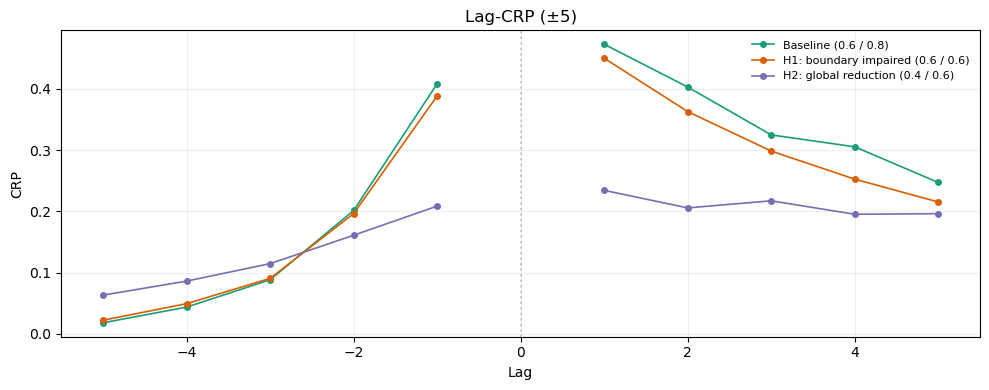

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, s in summaries.items():
    lag_vals, crp = s['whole_lag_crp']

    neg_mask = (lag_vals >= -5) & (lag_vals < 0)
    pos_mask = (lag_vals <= 5) & (lag_vals > 0)

    ax.plot(
        lag_vals[neg_mask], crp[neg_mask],
        marker='o', ms=4, lw=1.2,
        label=label, color=COLORS[label]
    )
    ax.plot(
        lag_vals[pos_mask], crp[pos_mask],
        marker='o', ms=4, lw=1.2,
        color=COLORS[label]
    )

ax.axvline(0, color='grey', ls=':', alpha=0.4)
ax.set(
    xlabel='Lag',
    ylabel='CRP',
    title='Lag-CRP (±5)'
)
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Boundary-local transitions

Three lag-1 transitions defined relative to each boundary position $j$, pooled across both boundaries:

- **(j−1) → j** — does recall cross *into* the new context?
- **j → (j−1)** — does the boundary item pull recall backward?
- **j → (j+1)** — does the boundary item push recall forward?

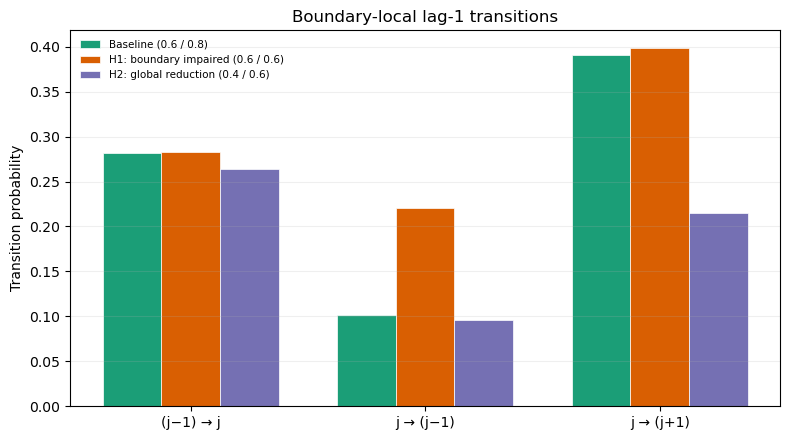

In [9]:
trans_labels = ['(j−1) → j', 'j → (j−1)', 'j → (j+1)']
keys = ['pre_to_boundary', 'boundary_backward', 'boundary_forward']

x = np.arange(len(trans_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (label, s) in enumerate(summaries.items()):
    vals = [s[k] for k in keys]
    ax.bar(x + (i - 1) * width, vals, width, label=label,
           color=COLORS[label], edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(trans_labels)
ax.set_ylabel('Transition probability')
ax.set_title('Boundary-local lag-1 transitions')
ax.legend(fontsize=7.5, frameon=False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### Boundary-local SPC

SPC in a ±4-position window around each boundary, averaged across both boundary positions. Position 0 on the x-axis is the boundary item itself.

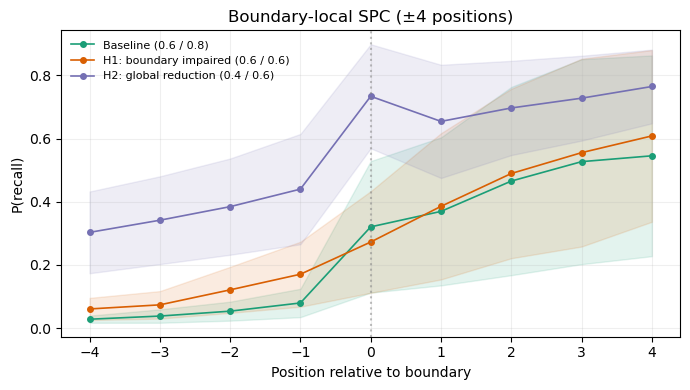

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, s in summaries.items():
    rel, mspc, se = s['boundary_local_spc']
    ax.plot(rel, mspc, marker='o', ms=4, lw=1.2,
            label=label, color=COLORS[label])
    ax.fill_between(rel, mspc - se, mspc + se, alpha=0.12,
                    color=COLORS[label])
ax.axvline(0, color='grey', ls=':', alpha=0.5)
ax.set(xlabel='Position relative to boundary',
       ylabel='P(recall)',
       title='Boundary-local SPC (±4 positions)')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Overall proportion recalled

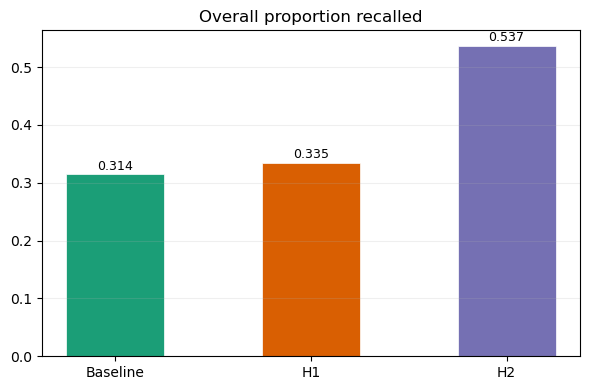

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
labels_short = ['Baseline', 'H1', 'H2']
accs = [summaries[l]['recall_accuracy'] for l in summaries]
bars = ax.bar(labels_short, accs,
              color=[COLORS[l] for l in summaries],
              edgecolor='white', linewidth=0.5, width=0.5)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, a + 0.003,
            f'{a:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Overall proportion recalled')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### Proportion recalled by contextual segment

Each train is a segment of the list defined by boundary positions. For the current design: Train 1 = positions 1–6, Train 2 = 7–12, Train 3 = 13–18.

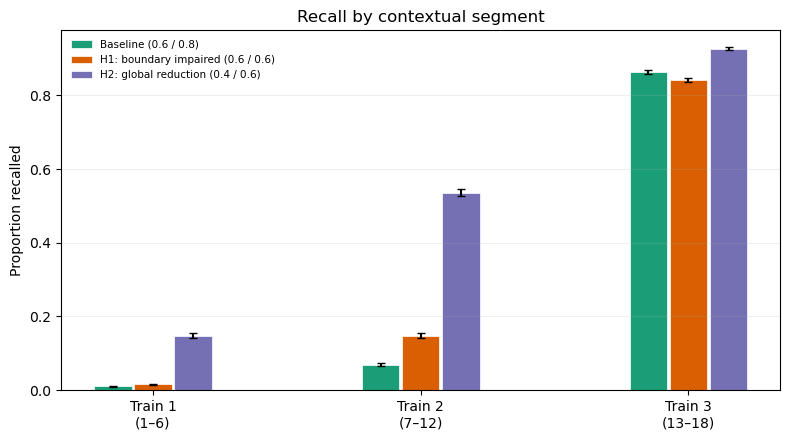

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x_offset = np.linspace(-0.15, 0.15, len(summaries))

for i, (label, s) in enumerate(summaries.items()):
    train_ids, mean_tr, se_tr = s['train_recall']
    x = train_ids + x_offset[i]
    ax.bar(x, mean_tr, width=0.14, yerr=se_tr, capsize=3,
           label=label, color=COLORS[label], edgecolor='white', linewidth=0.5)

ax.set_xticks(train_ids)
bounds = list(summaries.values())[0]['train_bounds']
ax.set_xticklabels([f"Train {t}\n({b[0]}–{b[1]})" for t, b in zip(train_ids, bounds)])
ax.set_ylabel('Proportion recalled')
ax.set_title('Recall by contextual segment')
ax.legend(fontsize=7.5, frameon=False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### Summary panel

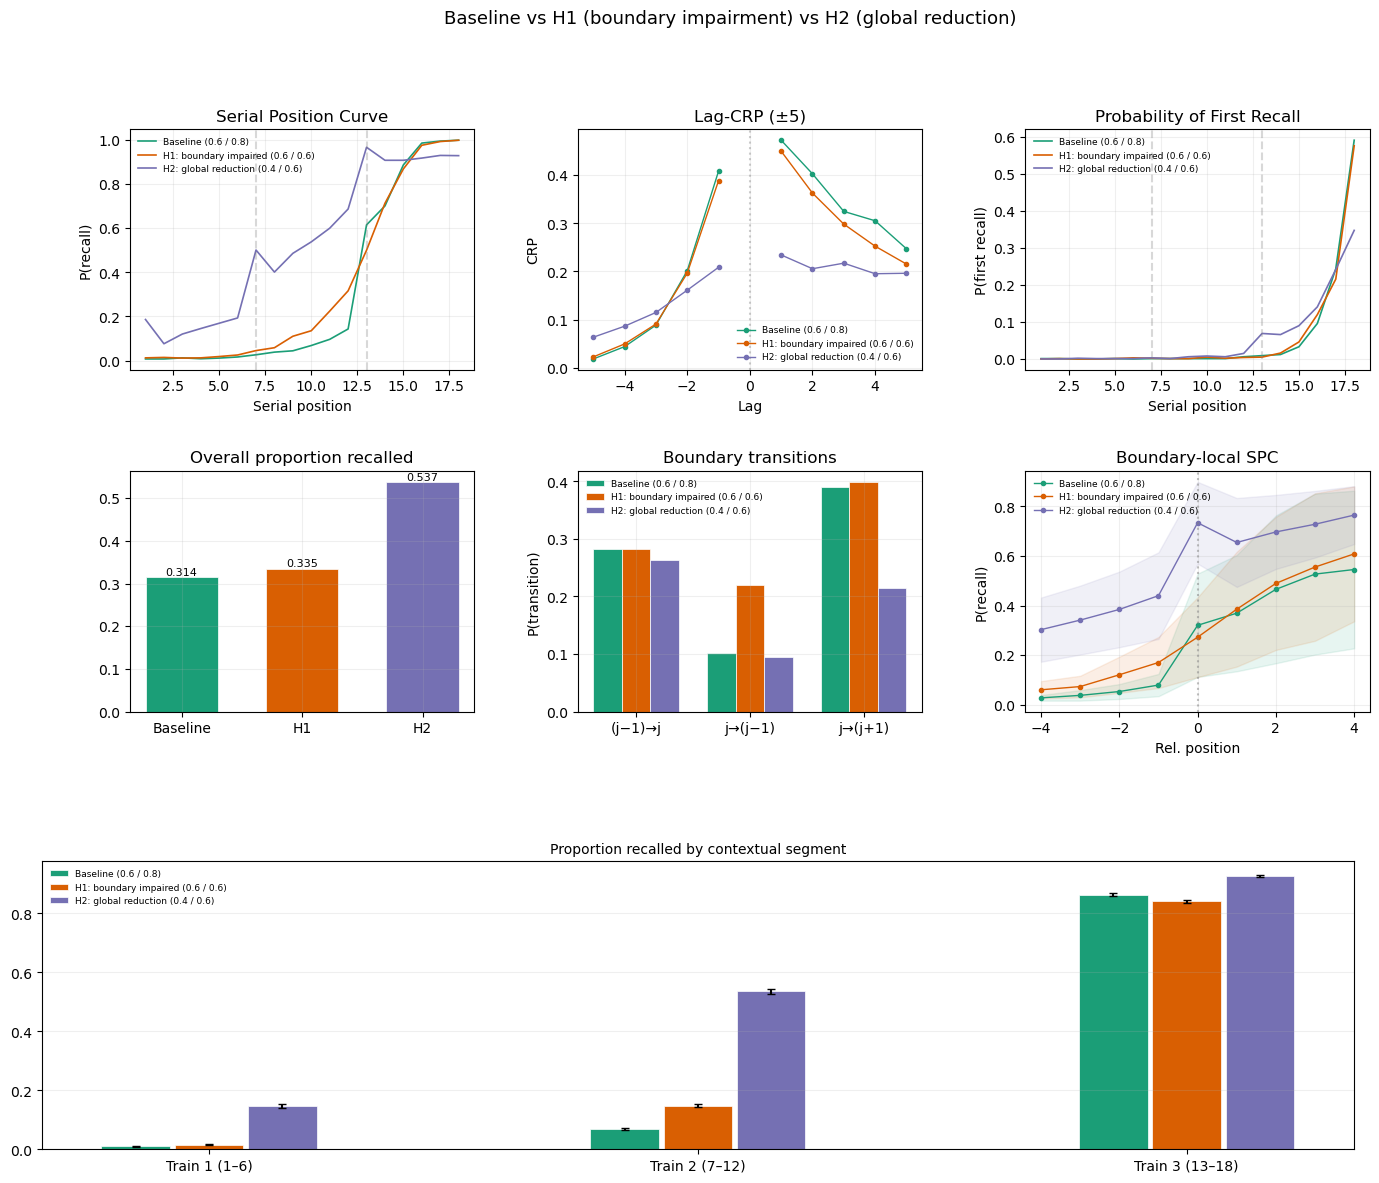

In [13]:
labels_in_order = list(summaries.keys())
labels_short = ['Baseline', 'H1', 'H2'][:len(labels_in_order)]

fig, axs = plt.subplots(3, 3, figsize=(16, 12))
fig.subplots_adjust(wspace=0.30, hspace=0.42)

# ── (0, 0) Whole-list SPC ──
for label, s in summaries.items():
    axs[0, 0].plot(
        positions,
        s['whole_spc'],
        lw=1.2,
        label=label,
        color=COLORS[label]
    )
for j in bps:
    axs[0, 0].axvline(j, color='grey', ls='--', alpha=0.3)

axs[0, 0].set(
    xlabel='Serial position',
    ylabel='P(recall)',
    title='Serial Position Curve'
)
axs[0, 0].legend(fontsize=6.5, frameon=False)
axs[0, 0].grid(alpha=0.2)

# ── (0, 1) Whole-list lag-CRP ──
for label, s in summaries.items():
    lv, crp = s['whole_lag_crp']
    neg = (lv >= -5) & (lv < 0)
    pos = (lv > 0) & (lv <= 5)

    axs[0, 1].plot(
        lv[neg],
        crp[neg],
        marker='o',
        ms=3,
        lw=1,
        label=label,
        color=COLORS[label]
    )
    axs[0, 1].plot(
        lv[pos],
        crp[pos],
        marker='o',
        ms=3,
        lw=1,
        color=COLORS[label]
    )

axs[0, 1].axvline(0, color='grey', ls=':', alpha=0.4)
axs[0, 1].set(
    xlabel='Lag',
    ylabel='CRP',
    title='Lag-CRP (±5)'
)
axs[0, 1].legend(fontsize=6.5, frameon=False)
axs[0, 1].grid(alpha=0.2)

# ── (0, 2) Whole-list PFR ──
for label, s in summaries.items():
    axs[0, 2].plot(
        positions,
        s['whole_pfr'],
        lw=1.2,
        label=label,
        color=COLORS[label]
    )
for j in bps:
    axs[0, 2].axvline(j, color='grey', ls='--', alpha=0.3)

axs[0, 2].set(
    xlabel='Serial position',
    ylabel='P(first recall)',
    title='Probability of First Recall'
)
axs[0, 2].legend(fontsize=6.5, frameon=False)
axs[0, 2].grid(alpha=0.2)

# ── (1, 0) Overall proportion recalled ──
accs = [summaries[label]['recall_accuracy'] for label in labels_in_order]
bars = axs[1, 0].bar(
    labels_short,
    accs,
    color=[COLORS[label] for label in labels_in_order],
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)
for bar, a in zip(bars, accs):
    axs[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        a + 0.001,
        f'{a:.3f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

axs[1, 0].set_title('Overall proportion recalled')
axs[1, 0].grid(alpha=0.2)

# ── (1, 1) Boundary transitions ──
trans_labels = ['(j−1)→j', 'j→(j−1)', 'j→(j+1)']
keys = ['pre_to_boundary', 'boundary_backward', 'boundary_forward']
x = np.arange(len(trans_labels))
w = 0.25

for i, (label, s) in enumerate(summaries.items()):
    vals = [s[k] for k in keys]
    axs[1, 1].bar(
        x + (i - 1) * w,
        vals,
        w,
        label=label,
        color=COLORS[label],
        edgecolor='white',
        linewidth=0.5
    )

axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(trans_labels)
axs[1, 1].set(
    ylabel='P(transition)',
    title='Boundary transitions'
)
axs[1, 1].legend(fontsize=6.5, frameon=False)
axs[1, 1].grid(alpha=0.2)

# ── (1, 2) Boundary-local SPC ──
for label, s in summaries.items():
    rel, mspc, se = s['boundary_local_spc']
    axs[1, 2].plot(
        rel,
        mspc,
        marker='o',
        ms=3,
        lw=1,
        label=label,
        color=COLORS[label]
    )
    axs[1, 2].fill_between(
        rel,
        mspc - se,
        mspc + se,
        alpha=0.10,
        color=COLORS[label]
    )

axs[1, 2].axvline(0, color='grey', ls=':', alpha=0.5)
axs[1, 2].set(
    xlabel='Rel. position',
    ylabel='P(recall)',
    title='Boundary-local SPC'
)
axs[1, 2].legend(fontsize=6.5, frameon=False)
axs[1, 2].grid(alpha=0.2)

# ── (2, 0–2) Segment-conditional recall: hide placeholders ──
for col_ax in axs[2, :]:
    col_ax.axis('off')

# Add one wide axis across bottom row
ax_train = fig.add_axes([0.07, 0.03, 0.82, 0.24])

train_ids_ref, mean_tr_ref, _ = list(summaries.values())[0]['train_recall']
bounds = list(summaries.values())[0]['train_bounds']
x_offset = np.linspace(-0.15, 0.15, len(summaries))

for i, (label, s) in enumerate(summaries.items()):
    t_ids, m_tr, se_tr = s['train_recall']
    xpos = t_ids + x_offset[i]
    ax_train.bar(
        xpos,
        m_tr,
        width=0.14,
        yerr=se_tr,
        capsize=3,
        label=label,
        color=COLORS[label],
        edgecolor='white',
        linewidth=0.5
    )

ax_train.set_xticks(train_ids_ref)
ax_train.set_xticklabels([
    f"Train {t} ({b[0]}–{b[1]})"
    for t, b in zip(train_ids_ref, bounds)
])
ax_train.set_title('Proportion recalled by contextual segment', fontsize=10)
ax_train.legend(fontsize=6.5, frameon=False)
ax_train.grid(axis='y', alpha=0.2)

fig.suptitle(
    'Baseline vs H1 (boundary impairment) vs H2 (global reduction)',
    fontsize=13,
    y=0.98
)
plt.show()

### Why overall recall proportion is low

Overall recall proportion is a whole-list summary: `recall_accuracy` computes the mean of # unique recalled items / N across simulations (`metrics.py`, lines 123–137).
>  What fraction of the entire studied list was successfully recovered?

This is not comparable to recall accuracies/proportion recalled reported in 2009, 2019, 2024 papers, which are reporting different dependent measures. 

- Rouhani (2024) reports proportion of successful retrievals for a **primed tested pair**, which is a *conditional pairwise retrieval success measure*.

- Although Polyn (2009) is also a free-recall model, its outputs are analyzed through **train-level proportion recalled** (in addition to SPC, lag-CRPs, source clustering, inter-response times).

- Talmi (2019) focuses on *relative recall proportions* rather than on global recall proportions (e.g., emotional vs. neutral advantage).

#### Polyn (2009): train-level proportion recalled

- This a more *local* metric: it measures how recall changes as a function of an item's position **within a same-source run / train**. 
  - a train is a kind of **contextual unit**.
- So train-level measure preserves *structural organization*.
  - conceptually closer to measures within a contextual segment.

- In contrast, whole-list overall recall score compresses all list positions and all local contexts into one scalar, and misses:
  - local clustering,
  - same-context support,
  - disruption at boundaries.

## Segment-conditional metrics

### Setup

In [14]:
# Choose segment
SEGMENT_ID = 3   # 1, 2, or 3

# Reuse train bounds already computed
segment_bounds = list(summaries.values())[0]['train_bounds']
segment_ids = list(summaries.values())[0]['train_recall'][0]

seg_start, seg_end = segment_bounds[SEGMENT_ID - 1]
seg_len = seg_end - seg_start + 1
seg_positions = np.arange(1, seg_len + 1)
seg_orig_positions = np.arange(seg_start, seg_end + 1)

# If the segment starts at a list boundary, keep that for boundary-local checks
SEGMENT_BOUNDARY = seg_start if seg_start in bps else None

print(f"Focal segment: {SEGMENT_ID}  ({seg_start}–{seg_end}), length = {seg_len}")
print(f"Segment-start boundary used for boundary-local checks: {SEGMENT_BOUNDARY}")

Focal segment: 3  (13–18), length = 6
Segment-start boundary used for boundary-local checks: 13


### Segment-conditional summaries

In [15]:
segment_summaries = met.summarize_segment_metrics(
    results,
    start=seg_start,
    end=seg_end,
    N=N,
    boundary_pos=SEGMENT_BOUNDARY,
    half_window=4,
)

print(f"{'Condition':<40s}  {'SegAcc':>8s}")
print('-' * 60)
for label, s in segment_summaries.items():
    print(f"{label:<40s}  {s['segment_accuracy']:8.4f}")

if SEGMENT_BOUNDARY is not None:
    print("\nBoundary-local checks at segment start:")
    print(f"{'Condition':<40s}  {'(j-1)→j':>8s}  {'j→(j-1)':>8s}  {'j→(j+1)':>8s}")
    print('-' * 80)
    for label, s in segment_summaries.items():
        print(
            f"{label:<40s}  "
            f"{s['boundary_pre_to_boundary']:8.4f}  "
            f"{s['boundary_backward']:8.4f}  "
            f"{s['boundary_forward']:8.4f}"
        )

Condition                                   SegAcc
------------------------------------------------------------
Baseline (0.6 / 0.8)                        0.8638
H1: boundary impaired (0.6 / 0.6)           0.8417
H2: global reduction (0.4 / 0.6)            0.9267

Boundary-local checks at segment start:
Condition                                  (j-1)→j   j→(j-1)   j→(j+1)
--------------------------------------------------------------------------------
Baseline (0.6 / 0.8)                        0.3333    0.1040    0.3992
H1: boundary impaired (0.6 / 0.6)           0.3028    0.2369    0.4467
H2: global reduction (0.4 / 0.6)            0.3275    0.1110    0.2446


### Segment-conditional SPC

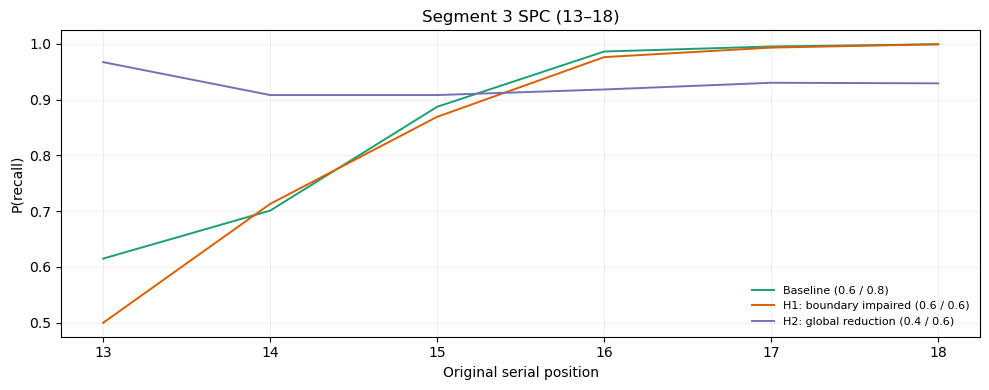

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, s in segment_summaries.items():
    ax.plot(
        seg_orig_positions,
        s['segment_spc'],
        lw=1.4,
        label=label,
        color=COLORS[label]
    )

ax.set(
    xlabel='Original serial position',
    ylabel='P(recall)',
    title=f'Segment {SEGMENT_ID} SPC ({seg_start}–{seg_end})'
)
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Segment-conditional Probability of First Recall

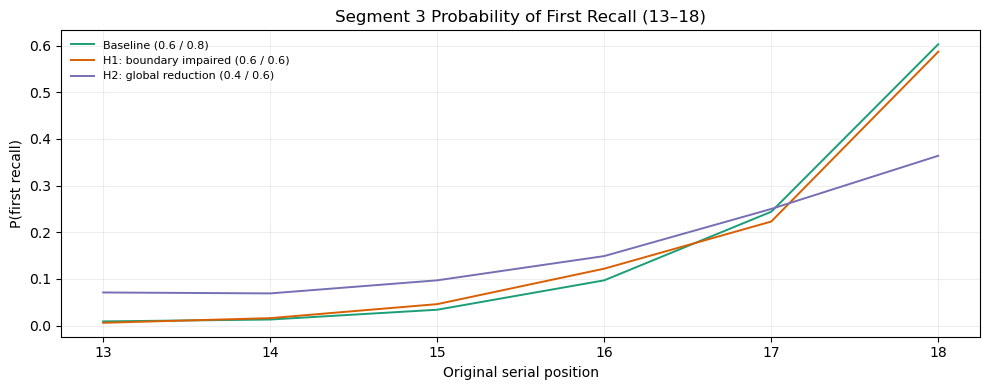

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, s in segment_summaries.items():
    ax.plot(
        seg_orig_positions,
        s['segment_pfr'],
        lw=1.4,
        label=label,
        color=COLORS[label]
    )

ax.set(
    xlabel='Original serial position',
    ylabel='P(first recall)',
    title=f'Segment {SEGMENT_ID} Probability of First Recall ({seg_start}–{seg_end})'
)
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Segment-conditional proportion recalled

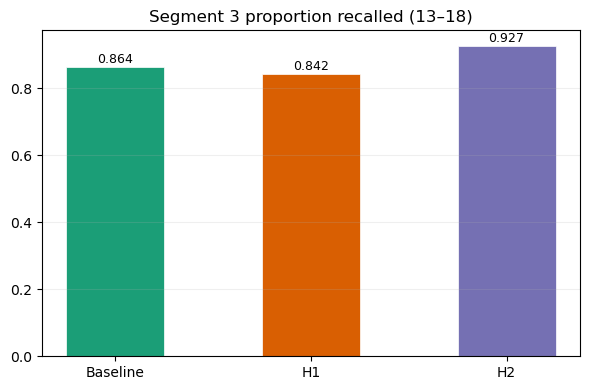

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

labels_in_order = list(segment_summaries.keys())
labels_short = ['Baseline', 'H1', 'H2'][:len(labels_in_order)]
accs = [segment_summaries[label]['segment_accuracy'] for label in labels_in_order]

bars = ax.bar(
    labels_short,
    accs,
    color=[COLORS[label] for label in labels_in_order],
    edgecolor='white',
    linewidth=0.5,
    width=0.5
)

for bar, a in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        a + 0.003,
        f'{a:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title(f'Segment {SEGMENT_ID} proportion recalled ({seg_start}–{seg_end})')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### Segment-start lag-1 transitions

Only meaningful for segments whose first item is a true list boundary.

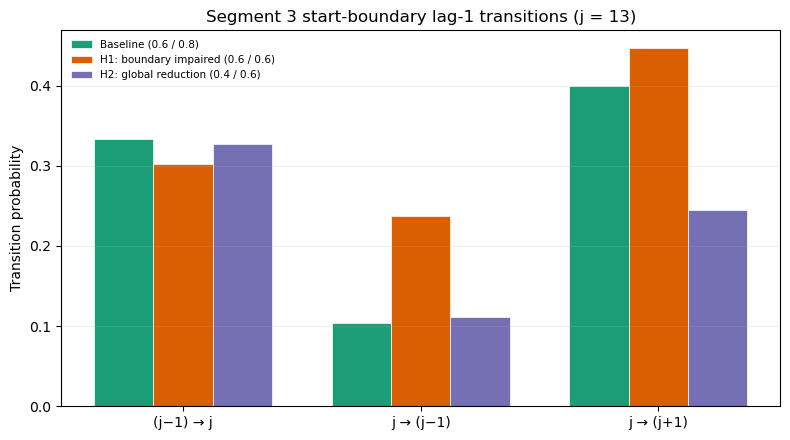

In [19]:
if SEGMENT_BOUNDARY is None:
    print(f"Segment {SEGMENT_ID} does not begin at a true list boundary, so this plot is skipped.")
else:
    trans_labels = ['(j−1) → j', 'j → (j−1)', 'j → (j+1)']
    keys = ['boundary_pre_to_boundary', 'boundary_backward', 'boundary_forward']

    x = np.arange(len(trans_labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (label, s) in enumerate(segment_summaries.items()):
        vals = [s[k] for k in keys]
        ax.bar(
            x + (i - 1) * width,
            vals,
            width,
            label=label,
            color=COLORS[label],
            edgecolor='white',
            linewidth=0.5
        )

    ax.set_xticks(x)
    ax.set_xticklabels(trans_labels)
    ax.set_ylabel('Transition probability')
    ax.set_title(f'Segment {SEGMENT_ID} start-boundary lag-1 transitions (j = {SEGMENT_BOUNDARY})')
    ax.legend(fontsize=7.5, frameon=False)
    ax.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()

### Segment-start SPC

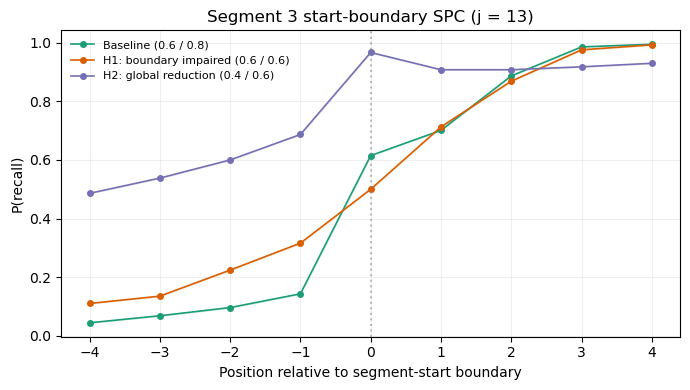

In [20]:
if SEGMENT_BOUNDARY is None:
    print(f"Segment {SEGMENT_ID} does not begin at a true list boundary, so this plot is skipped.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))

    for label, s in segment_summaries.items():
        rel, mspc, se = s['boundary_local_spc']
        ax.plot(
            rel,
            mspc,
            marker='o',
            ms=4,
            lw=1.2,
            label=label,
            color=COLORS[label]
        )
        ax.fill_between(
            rel,
            mspc - se,
            mspc + se,
            alpha=0.12,
            color=COLORS[label]
        )

    ax.axvline(0, color='grey', ls=':', alpha=0.5)
    ax.set(
        xlabel='Position relative to segment-start boundary',
        ylabel='P(recall)',
        title=f'Segment {SEGMENT_ID} start-boundary SPC (j = {SEGMENT_BOUNDARY})'
    )
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Summary panel

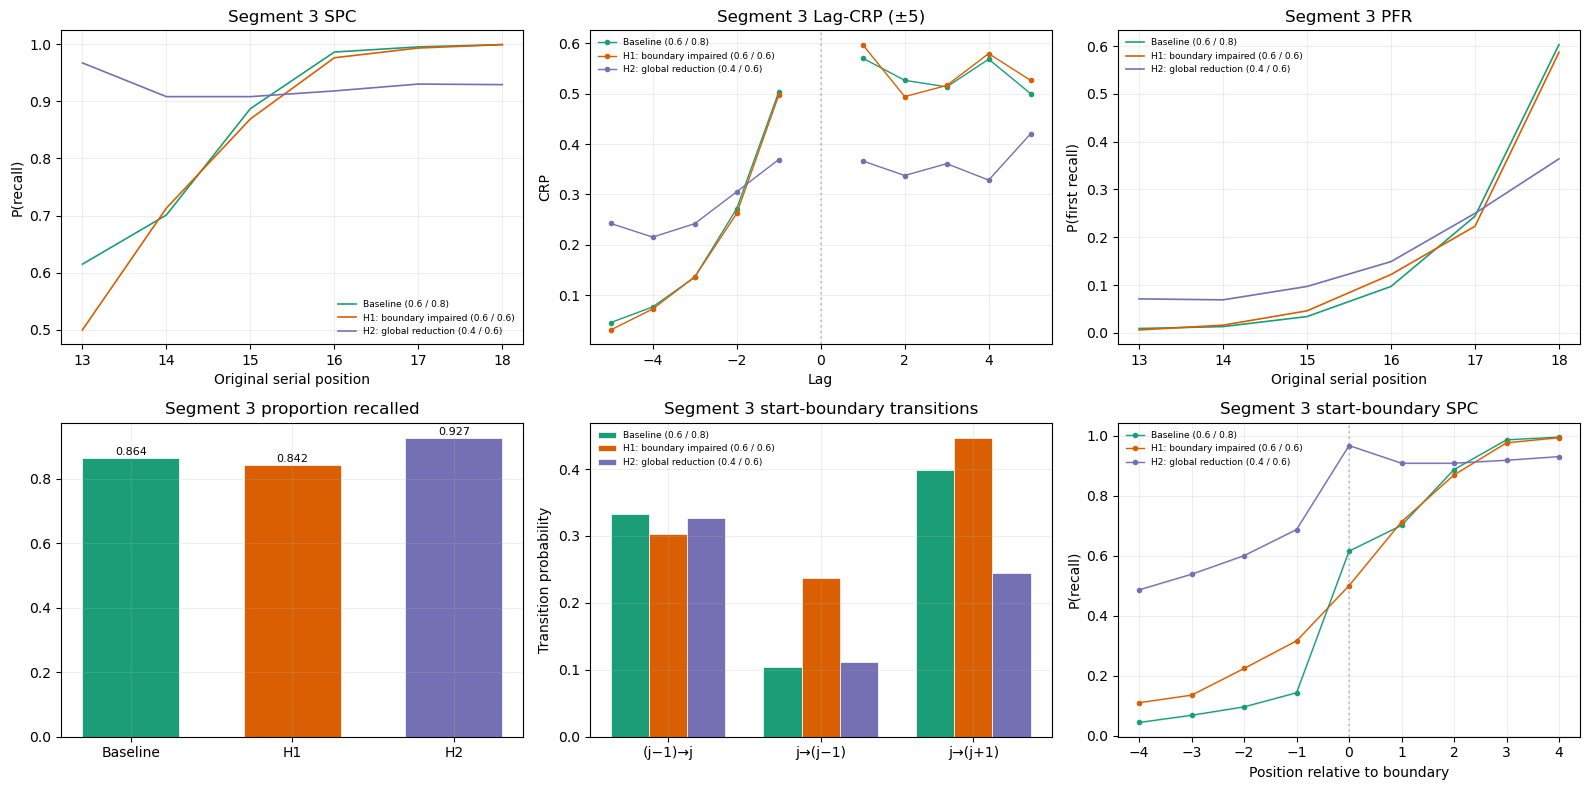

In [21]:
labels_in_order = list(segment_summaries.keys())
labels_short = ['Baseline', 'H1', 'H2'][:len(labels_in_order)]
max_plot_lag = min(5, seg_len - 1)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
fig.subplots_adjust(wspace=0.30, hspace=0.38)

# ── (0, 0) Segment SPC ──
for label, s in segment_summaries.items():
    axs[0, 0].plot(
        seg_orig_positions,
        s['segment_spc'],
        lw=1.2,
        label=label,
        color=COLORS[label]
    )
axs[0, 0].set(
    xlabel='Original serial position',
    ylabel='P(recall)',
    title=f'Segment {SEGMENT_ID} SPC'
)
axs[0, 0].legend(fontsize=6.5, frameon=False)
axs[0, 0].grid(alpha=0.2)

# ── (0, 1) Segment lag-CRP ──
for label, s in segment_summaries.items():
    lv, crp = s['segment_lag_crp']
    neg = (lv >= -max_plot_lag) & (lv < 0)
    pos = (lv > 0) & (lv <= max_plot_lag)

    axs[0, 1].plot(
        lv[neg],
        crp[neg],
        marker='o',
        ms=3,
        lw=1,
        label=label,
        color=COLORS[label]
    )
    axs[0, 1].plot(
        lv[pos],
        crp[pos],
        marker='o',
        ms=3,
        lw=1,
        color=COLORS[label]
    )

axs[0, 1].axvline(0, color='grey', ls=':', alpha=0.4)
axs[0, 1].set(
    xlabel='Lag',
    ylabel='CRP',
    title=f'Segment {SEGMENT_ID} Lag-CRP (±{max_plot_lag})'
)
axs[0, 1].legend(fontsize=6.5, frameon=False)
axs[0, 1].grid(alpha=0.2)

# ── (0, 2) Segment PFR ──
for label, s in segment_summaries.items():
    axs[0, 2].plot(
        seg_orig_positions,
        s['segment_pfr'],
        lw=1.2,
        label=label,
        color=COLORS[label]
    )
axs[0, 2].set(
    xlabel='Original serial position',
    ylabel='P(first recall)',
    title=f'Segment {SEGMENT_ID} PFR'
)
axs[0, 2].legend(fontsize=6.5, frameon=False)
axs[0, 2].grid(alpha=0.2)

# ── (1, 0) Segment accuracy ──
accs = [segment_summaries[label]['segment_accuracy'] for label in labels_in_order]
bars = axs[1, 0].bar(
    labels_short,
    accs,
    color=[COLORS[label] for label in labels_in_order],
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)

for bar, a in zip(bars, accs):
    axs[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        a + 0.003,
        f'{a:.3f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

axs[1, 0].set_title(f'Segment {SEGMENT_ID} proportion recalled')
axs[1, 0].grid(alpha=0.2)

if SEGMENT_BOUNDARY is None:
    axs[1, 1].axis('off')
    axs[1, 2].axis('off')
else:
    # ── (1, 1) Boundary transitions at segment start ──
    trans_labels = ['(j−1)→j', 'j→(j−1)', 'j→(j+1)']
    keys = ['boundary_pre_to_boundary', 'boundary_backward', 'boundary_forward']
    x = np.arange(len(trans_labels))
    width = 0.25

    for i, (label, s) in enumerate(segment_summaries.items()):
        vals = [s[k] for k in keys]
        axs[1, 1].bar(
            x + (i - 1) * width,
            vals,
            width,
            label=label,
            color=COLORS[label],
            edgecolor='white',
            linewidth=0.5
        )

    axs[1, 1].set_xticks(x)
    axs[1, 1].set_xticklabels(trans_labels)
    axs[1, 1].set_ylabel('Transition probability')
    axs[1, 1].set_title(f'Segment {SEGMENT_ID} start-boundary transitions')
    axs[1, 1].legend(fontsize=6.5, frameon=False)
    axs[1, 1].grid(alpha=0.2)

    # ── (1, 2) Boundary-local SPC at segment start ──
    for label, s in segment_summaries.items():
        rel, mspc, se = s['boundary_local_spc']
        axs[1, 2].plot(
            rel,
            mspc,
            marker='o',
            ms=3,
            lw=1,
            label=label,
            color=COLORS[label]
        )
        axs[1, 2].fill_between(
            rel,
            mspc - se,
            mspc + se,
            alpha=0.12,
            color=COLORS[label]
        )

    axs[1, 2].axvline(0, color='grey', ls=':', alpha=0.4)
    axs[1, 2].set(
        xlabel='Position relative to boundary',
        ylabel='P(recall)',
        title=f'Segment {SEGMENT_ID} start-boundary SPC'
    )
    axs[1, 2].legend(fontsize=6.5, frameon=False)
    axs[1, 2].grid(alpha=0.2)

plt.tight_layout()
plt.show()